In [51]:
# CPSC 483 Final Project

## Breast Cancer Diagnosis Prediction Using Machine Learning

## 1. Problem Statement

This project uses machine learning to predict whether a tumor is benign or malignant based on diagnostic measurements.

Task:
Binary classification.

Goal:
Support early disease detection using predictive modeling.

## 2. Dataset Description

This project uses the 
:contentReference[oaicite:0]{index=0}
available through the
:contentReference[oaicite:1]{index=1}.

The dataset contains diagnostic measurements computed from digitized images of breast masses.

Features include:
- Mean radius
- Mean texture
- Mean perimeter
- Mean area
- Mean smoothness
- Additional diagnostic tumor measurements

Target Variable:
- 0 = Malignant
- 1 = Benign

The dataset contains 569 observations and 30 predictive features.

## 3. Data Preprocessing

Preprocessing steps included:

- Loading the dataset into a pandas DataFrame
- Separating predictor variables (X) and target labels (y)
- Splitting data into training and testing sets using an 80/20 split
- Using a fixed random_state for reproducibility

Because this dataset was already clean and curated, minimal preprocessing was required.

## 4. Model Selection

Two supervised machine learning models were selected:

1. :contentReference[oaicite:2]{index=2}
- Used as a baseline classification model
- Chosen for interpretability and efficiency

2. :contentReference[oaicite:3]{index=3}
- Chosen for stronger predictive performance
- Captures nonlinear relationships in data

These models were compared based on classification performance.

## Model Comparison

Two classification models were evaluated:

- Logistic Regression: 95.6% accuracy
- Random Forest: 96.5% accuracy

Random Forest achieved slightly higher predictive performance.

## 5. Experiments and Evaluation

## Evaluation Metrics

Two models were evaluated using accuracy, precision, recall, and F1-score.

Logistic Regression:
- Accuracy: 95.6%

Random Forest:
- Accuracy: 96.5%
- Precision: 97%
- Recall: 96%
- F1-Score: 96%

The Random Forest model slightly outperformed Logistic Regression and was selected as the stronger model overall.

Accuracy was used to measure overall predictive performance.

Precision and recall were included because in medical diagnosis false positives and false negatives are important considerations.

F1-score was used to balance precision and recall.

## 6. Results and Discussion

Both models performed well, with Random Forest slightly outperforming Logistic Regression.

Possible reasons:
- Random Forest captures more complex patterns
- Ensemble methods reduce overfitting
- Medical diagnostic features may have nonlinear relationships
    
## Results and Discussion

The Logistic Regression model achieved 95.6% accuracy on the test set, showing strong predictive performance for tumor classification.

## 7. Limitations and Future Work

Limitations:
- Dataset is relatively small
- Results may not generalize to all clinical populations
- Models should support, not replace, medical professionals

Future Work:
- Evaluate additional models
- Use larger medical datasets
- Explore neural networks
- Build a clinical decision support application

## 8. Conclusion

This project compared Logistic Regression and Random Forest models for breast cancer diagnosis prediction.

Both models performed well, with Random Forest achieving the strongest performance at 96.5% accuracy.

Results suggest machine learning can support early disease classification and demonstrate the usefulness of predictive models in healthcare.

SyntaxError: invalid syntax (1675726206.py, line 7)

In [33]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train,y_train)

print(
"Logistic Regression Accuracy:",
model.score(X_test,y_test)
)

Logistic Regression Accuracy: 0.956140350877193


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

print(
"Random Forest Accuracy:",
rf.score(X_test,y_test)
)

Random Forest Accuracy: 0.9649122807017544


In [41]:
from sklearn.metrics import classification_report

predictions = rf.predict(X_test)

print(
classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



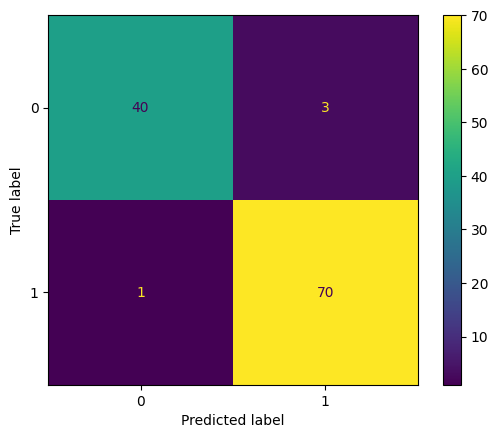

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

In [52]:
import pandas as pd

importance = pd.Series(
rf.feature_importances_,
index=data.feature_names
).sort_values(ascending=False)

print(importance.head(10))

worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
mean perimeter          0.053270
mean radius             0.048703
mean area               0.047555
worst concavity         0.031802
dtype: float64


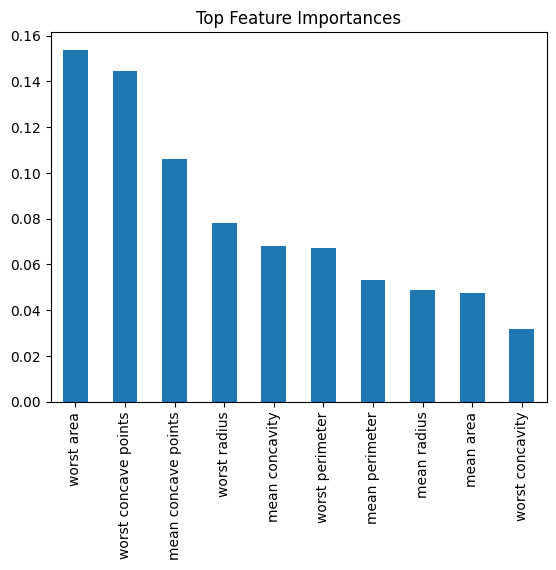

In [53]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()